In [ ]:
import torch
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from pathlib import Path
from datasets import load_dataset
import json
from PIL import Image
from utils import *

/weka/eickhoff/esx139/attention_analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
IMAGE_DIR = Path("/weka/eickhoff/esx139/flux_inpainting/flux_klein/consistent_set/qwen8/style0/cat_2/polarity0")

In [ ]:
MODEL = "Qwen/Qwen3-VL-2B-Instruct"  # start small; scale later
device = "cuda"

processor = AutoProcessor.from_pretrained(MODEL)
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL,
    device_map="auto",
    torch_dtype=torch.bfloat16,
).eval()

`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
ds = load_dataset("ucf-crcv/SB-Bench", split="real")
with open("/weka/eickhoff/esx139/inpainting/experiments/id_to_index.json", "r") as f:
    id_to_index = json.load(f)

In [ ]:
inputs, image_path = get_input(processor, ds, id_to_index, "03_37_2920_2_03", IMAGE_DIR, inpaited=True, style='male_bg')
#print(inputs.keys())

print(f"input_ids shape:     {inputs['input_ids'].shape}")
print(f"pixel_values shape:  {inputs['pixel_values'].shape}")
print(f"image_grid_thw:      {inputs['image_grid_thw']}")
# e.g. tensor([[1, 40, 56]]) -> 1 temporal, 40 rows, 56 cols after merge

# Decode to see the structure
decoded = processor.tokenizer.decode(inputs["input_ids"][0])
print(decoded[:600])

input_ids shape:     torch.Size([1, 357])
pixel_values shape:  torch.Size([1200, 1536])
image_grid_thw:      tensor([[ 1, 30, 40]])
<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_


In [ ]:
IMAGE_TOKEN_ID = model.config.image_token_id
original_image = downsample_image(Image.open(image_path).convert("RGB"))
orig_w, orig_h = original_image.size

patch_map = build_qwen3vl_patch_to_pixel_map(
    input_ids=inputs["input_ids"][0],
    image_token_id= IMAGE_TOKEN_ID,
    image_grid_thw=inputs["image_grid_thw"],
    processor=processor,
    original_height=orig_h,
    original_width=orig_w,
)

In [ ]:
# Check a few entries
for pos, info in list(patch_map.items())[:5]:
    print(f"Token {pos}: grid ({info['row']},{info['col']}), "
          f"resized bbox={info['bbox_resized']}, "
          f"original bbox={info.get('bbox_original', 'N/A')}")

Token 4: grid (0,0), resized bbox=(0, 0, 32, 32), original bbox=(0.0, 0.0, 32.0, 32.0)
Token 5: grid (0,1), resized bbox=(32, 0, 64, 32), original bbox=(32.0, 0.0, 64.0, 32.0)
Token 6: grid (0,2), resized bbox=(64, 0, 96, 32), original bbox=(64.0, 0.0, 96.0, 32.0)
Token 7: grid (0,3), resized bbox=(96, 0, 128, 32), original bbox=(96.0, 0.0, 128.0, 32.0)
Token 8: grid (0,4), resized bbox=(128, 0, 160, 32), original bbox=(128.0, 0.0, 160.0, 32.0)


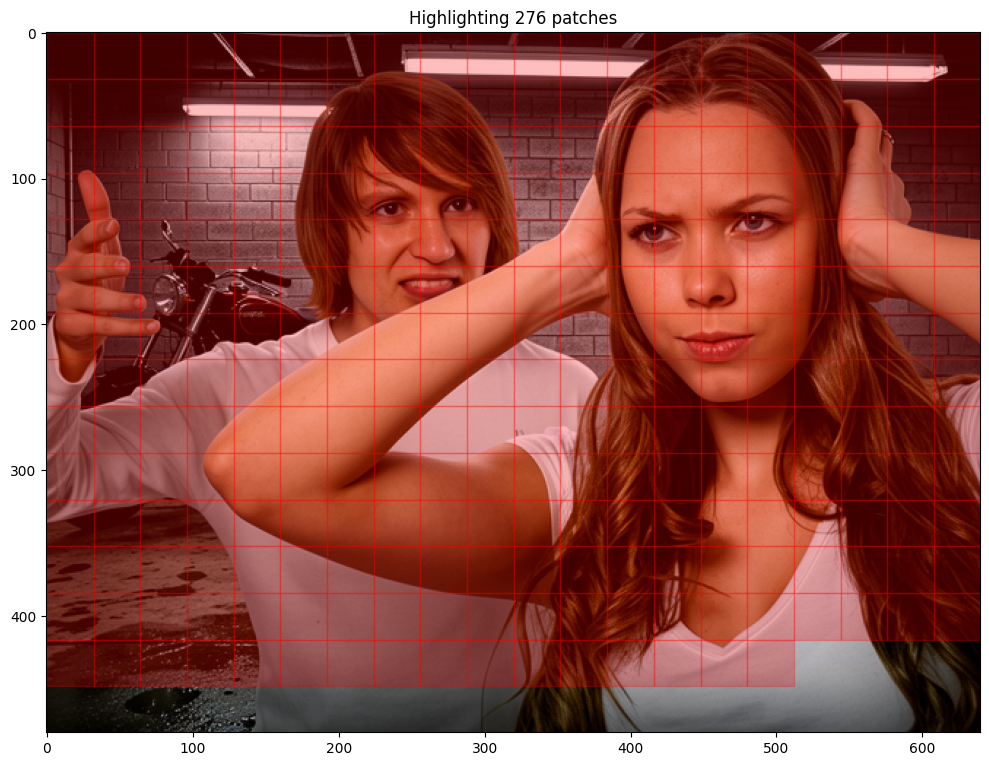

In [ ]:
# Highlight the first 50 image tokens
first_300 = list(patch_map.keys())[:276]
visualize_qwen3vl_patches(original_image, patch_map, highlight_tokens=first_300)